In [1]:
# Uppdaterar ändringar i src utan att behöva starta om kernel:

%load_ext autoreload 
%autoreload 2
%matplotlib inline


import sys
import os
import time

# Check kernel
print(f'path: {sys.executable}')

# Absolut path:
project_root = os.path.abspath(os.path.join(os.getcwd(), '..', '..' ))

print(project_root)

# Lägg till i sys path
if project_root not in sys.path:
    sys.path.append(project_root)
    print(f"Added '{project_root}' to sys.path")

from pathlib import Path
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

from heston_project.models.MLP import Heston_MLP
from heston_project.utils import *



# Device Configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Reproducibility 
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
if device.type == 'cuda':
    torch.cuda.manual_seed(SEED)

print("Setup Complete.")


path: /Users/manswestman/Kandidatarbete/venv/bin/python
/Users/manswestman/Kandidatarbete
Added '/Users/manswestman/Kandidatarbete' to sys.path
Using device: cpu
Setup Complete.


In [4]:

project_root = Path(project_root) 

df = pd.read_csv(project_root/'data'/'full_dataset_training_200000(2).csv')
# Shuffle with a fixed random state for reproducibility
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

df['v0']=np.sqrt(df['v0'])
df['theta']=np.sqrt(df['theta'])

'''
Hur ska vi testa generaliseting och hur ska vi göra med test set överlag???
'''

df_subset = df.copy() 
X_raw = df_subset[['kappa', 'v0', 'theta', 'rho', 'sigma', 'r', 'lm', 'T']] 
y_raw = df_subset['price']

X_train, X_val, y_train, y_val = train_test_split(X_raw, y_raw, test_size=0.1, random_state=42)

param_bounds = {
    "lm":    [-1.5, 1.5],
    "r":     [-0.01, 0.10],
    "T":     [1/52, 3.0],
    "theta": [0.0, 1.0],
    "sigma": [0.1, 1.5],
    "rho":   [-0.95, 0.0],
    "kappa": [0.05, 5.0],
    "v0":    [0.0, 1.0],
}

# Skalar till [-1,1]
def scale_to_unit(x, xmin, xmax):
    return 2 * (x - xmin) / (xmax - xmin) - 1

# Skalar till [0,1]
def price_scale(x, xmin, xmax,):
    return (x - xmin) / (xmax - xmin)


# Kopia så att vi inte redigerar OG

X_train_scaled = X_train.copy()
X_val_scaled = X_val.copy()

for k, (xmin, xmax) in param_bounds.items():
    X_train_scaled[k] = scale_to_unit(X_train_scaled[k], xmin, xmax)
    X_val_scaled[k]   = scale_to_unit(X_val_scaled[k], xmin, xmax)

ymin = y_train.min()
ymax = y_train.max()

y_train_scaled = price_scale(y_train, ymin, ymax)
y_val_scaled   = price_scale(y_val, ymin, ymax)

#y_train_scaled = np.sqrt(y_train)
#y_val_scaled   = np.sqrt(y_val)


#  .values för att få numpy array från df
train_dataset = TensorDataset(
    torch.tensor(X_train_scaled.values, dtype=torch.float32),             # Ska vi ha 32s??
    torch.tensor(y_train_scaled.values, dtype=torch.float32).unsqueeze(1) # Added unsqueeze!
)

val_dataset = TensorDataset(
    torch.tensor(X_val_scaled.values, dtype=torch.float32), 
    torch.tensor(y_val_scaled.values, dtype=torch.float32).unsqueeze(1) 
)

# OBS ha med ej fullständiga batcher?? (standard) (DVS ska vi ha droplast???)
train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=2048) # Bigger batch for val is fine (check for exact size)


In [5]:
# gpu om tillgänglig annars cpu
device = 'cuda' if torch.cuda.is_available() else 'cpu' # else 'mps' if torch.backends.mps.is_available()
print(f"Training on: {device}")

# initialisera modellen till device
model = Heston_MLP(input_dim=8, hidden_layers=7, neurons=250).to(device) # OBS 8 input och välj hyperparams

# Loss + Optimizer
criterion = nn.MSELoss()
optimizer = optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-5) # OBS vilken initial learning rate och weight size penalty ??
# scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5) # bestämer hur och när vi ska ändra lr
# lr på DNN: 3e-4
scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=150, T_mult=1, eta_min=1e-6)

Training on: cpu


In [6]:

import heston_project
PKG_DIR = Path(heston_project.__file__).resolve().parent
SAVE_DIR = PKG_DIR / "models" / "saved"
out_path = SAVE_DIR / "MLP_P_final.pth"

EPOCHS = 450

# Early stopping
patience_early_stopping = 450
best_val_loss = float('inf')
counter = 0

# Tracking loss
train_losses = []
val_losses = []

print(f'Starting Training on {device}...')
start_time = time.time()

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0

    for batch_X, batch_y in train_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)

        optimizer.zero_grad()                       # nollställ 
        predictions = model(batch_X)                # f(x) = y
        loss = criterion(predictions, batch_y)      # skicka in i MSE
        loss.backward()                             # beräknar loss gradient (backward-pass)
        optimizer.step()                            # w_new = w_old − η⋅∇L(w) (η = lr)
        
        running_loss += loss.item()

    avg_train_loss = running_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # Validation Phase
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for batch_X, batch_y in val_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            preds = model(batch_X)
            loss = criterion(preds, batch_y)
            val_loss += loss.item()
            
    avg_val_loss = val_loss / len(val_loader)
    val_losses.append(avg_val_loss)
    
    # Update Learning Rate
    scheduler.step()

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), out_path) # Save the best version
        counter = 0 # Reset counter
    else:
        counter += 1
        if counter >= patience_early_stopping:
            print(f"Early stopping triggered at epoch {epoch}")
            break
    
    if (epoch + 1) % 5 == 0:
        current_lr = optimizer.param_groups[0]['lr']
        print(f"Epoch [{epoch+1}/{EPOCHS}] | Train Loss: {avg_train_loss:.6e} | Val Loss: {avg_val_loss:.6e} | LR: {current_lr:.6e}")

end_time = time.time()
print(f"Training Finished. Total Time: {end_time - start_time:.2f} seconds")

print("*" * 70)
print(f"Best Val Loss -> Tot: {best_val_loss:.4e}")
print("*" * 70)

print("Reloading best model weights for testing...")
model.load_state_dict(torch.load(out_path))
model.eval()

Starting Training on cpu...
Epoch [5/450] | Train Loss: 2.001310e-05 | Val Loss: 3.402006e-05 | LR: 2.991810e-04
Epoch [10/450] | Train Loss: 1.767844e-05 | Val Loss: 3.807033e-06 | LR: 2.967331e-04
Epoch [15/450] | Train Loss: 7.078649e-06 | Val Loss: 7.085459e-06 | LR: 2.926829e-04
Epoch [20/450] | Train Loss: 5.242781e-06 | Val Loss: 1.462134e-06 | LR: 2.870750e-04
Epoch [25/450] | Train Loss: 4.624187e-06 | Val Loss: 5.125139e-06 | LR: 2.799708e-04
Epoch [30/450] | Train Loss: 3.034077e-06 | Val Loss: 9.525068e-07 | LR: 2.714480e-04
Epoch [35/450] | Train Loss: 1.239391e-06 | Val Loss: 7.322328e-07 | LR: 2.616002e-04
Epoch [40/450] | Train Loss: 3.345523e-06 | Val Loss: 3.730184e-07 | LR: 2.505350e-04
Epoch [45/450] | Train Loss: 4.198502e-06 | Val Loss: 4.406630e-07 | LR: 2.383739e-04
Epoch [50/450] | Train Loss: 1.377574e-06 | Val Loss: 4.552838e-07 | LR: 2.252500e-04
Epoch [55/450] | Train Loss: 1.612007e-06 | Val Loss: 1.907429e-07 | LR: 2.113071e-04
Epoch [60/450] | Train Loss

Heston_MLP(
  (softplus): Softplus(beta=1.0, threshold=20.0)
  (network): Sequential(
    (0): Linear(in_features=8, out_features=250, bias=True)
    (1): SiLU()
    (2): Linear(in_features=250, out_features=250, bias=True)
    (3): SiLU()
    (4): Linear(in_features=250, out_features=250, bias=True)
    (5): SiLU()
    (6): Linear(in_features=250, out_features=250, bias=True)
    (7): SiLU()
    (8): Linear(in_features=250, out_features=250, bias=True)
    (9): SiLU()
    (10): Linear(in_features=250, out_features=250, bias=True)
    (11): SiLU()
    (12): Linear(in_features=250, out_features=250, bias=True)
    (13): SiLU()
    (14): Linear(in_features=250, out_features=1, bias=True)
  )
)

In [6]:
loss_df = pd.DataFrame({
    "epoch": range(1, len(train_losses) + 1),
    "train_loss": train_losses,
    "val_loss": val_losses,
})

loss_df.to_csv("losses/loss_data/MLP_P_loss_history.csv", index=False)

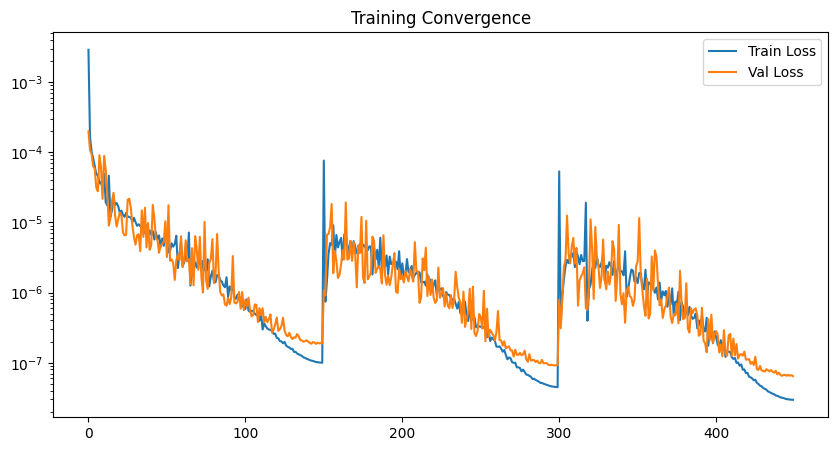

In [7]:
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.yscale('log') # Log scale is often better for MSE
plt.title('Training Convergence')
plt.legend()
plt.show()